In [1]:
!wget -O t10k-images.idx3-ubyte https://github.com/rohanp031/Handwritten-Digit-Recognition-with-LeNet5-Model-in-PyTorch/raw/main/MNIST_dataset/t10k-images.idx3-ubyte
!wget -O t10k-labels.idx1-ubyte https://github.com/rohanp031/Handwritten-Digit-Recognition-with-LeNet5-Model-in-PyTorch/raw/main/MNIST_dataset/t10k-labels.idx1-ubyte

--2024-06-11 14:27:34--  https://github.com/rohanp031/Handwritten-Digit-Recognition-with-LeNet5-Model-in-PyTorch/raw/main/MNIST_dataset/t10k-images.idx3-ubyte
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rohanp031/Handwritten-Digit-Recognition-with-LeNet5-Model-in-PyTorch/main/MNIST_dataset/t10k-images.idx3-ubyte [following]
--2024-06-11 14:27:35--  https://raw.githubusercontent.com/rohanp031/Handwritten-Digit-Recognition-with-LeNet5-Model-in-PyTorch/main/MNIST_dataset/t10k-images.idx3-ubyte
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7840016 (7.5M) [application/octet-stream]
Saving to: ‘

In [2]:
# Import the struct module to interpret bytes as packed binary data
import struct
# Import the numpy library for numerical operations
import numpy as np
# Import the matplotlib library for plotting
import matplotlib.pyplot as plt

def read_idx(filename):
  """
    Reads an IDX file and returns the data as a NumPy array.

    Parameters:
    filename (str): The path to the IDX file.

    Returns:
    np.ndarray: The data contained in the IDX file as a NumPy array.
    """
# Open the file in binary read mode
  with open(filename, 'rb') as f:
# Read the first 4 bytes, which contain metadata about the file
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
# Read the dimensions of the data
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
# Read the rest of the file content and convert it into a NumPy array
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)
# Load the images and labels from the IDX files
images = read_idx('t10k-images.idx3-ubyte')
labels = read_idx('t10k-labels.idx1-ubyte')



In [3]:
# Print the shape of the images array
print(f'Images shape: {images.shape}')
# Images shape: (num_images, height, width)
# This prints the dimensions of the images array. The shape is a tuple where:
# - The first element is the number of images.
# - The second element is the height of each image.
# - The third element is the width of each image.

# Print the shape of the labels array
print(f'Labels shape: {labels.shape}')
# Labels shape: (num_labels,)
# This prints the dimensions of the labels array. The shape is a tuple where:
# - The single element is the number of labels.
# Each label corresponds to an image.

# Print the number of images
print(f'Number of images: {len(images)}')
# Number of images: num_images
# This prints the number of images by getting the length of the images array.
# It should match the first element of the images shape.

# Print the number of labels
print(f'Number of labels: {len(labels)}')
# Number of labels: num_labels
# This prints the number of labels by getting the length of the labels array.
# It should match the number of images.

Images shape: (10000, 28, 28)
Labels shape: (10000,)
Number of images: 10000
Number of labels: 10000


In [4]:
import torch

# Assuming you've loaded your data using the provided functions
images = read_idx('t10k-images.idx3-ubyte')
labels = read_idx('t10k-labels.idx1-ubyte')

# Define LeNet input shape (assuming grayscale images)
leNet_input_shape = (1, 28, 28)

# Reshape images to match LeNet's input shape
reshaped_images = images.reshape(-1, *leNet_input_shape)  # Reshape with -1 for batch size

print("Original images shape:", images.shape)
print("Reshaped images shape:", reshaped_images.shape)

# Convert data type to float for PyTorch (optional, might be needed depending on your model)
reshaped_images = reshaped_images.astype(np.float32) / 255.0  # Normalize pixel values

print("Data type after reshaping:", reshaped_images.dtype)

Original images shape: (10000, 28, 28)
Reshaped images shape: (10000, 1, 28, 28)
Data type after reshaping: float32


In [5]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Define transformations for the dataset
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the datasets with the defined transformations
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Define a custom collate function for one-hot encoding
def one_hot_collate(batch, num_classes=10):
    images, labels = zip(*batch)
    images = torch.stack(images)
    labels = torch.tensor(labels)
    one_hot_labels = torch.nn.functional.one_hot(labels, num_classes=num_classes).float()
    return images, one_hot_labels

# Use the custom collate function in the DataLoader
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, collate_fn=lambda x: one_hot_collate(x))
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False, collate_fn=lambda x: one_hot_collate(x))

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9912422/9912422 [00:00<00:00, 13245772.42it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28881/28881 [00:00<00:00, 508027.89it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1648877/1648877 [00:00<00:00, 3708137.44it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4542/4542 [00:00<00:00, 9989789.60it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



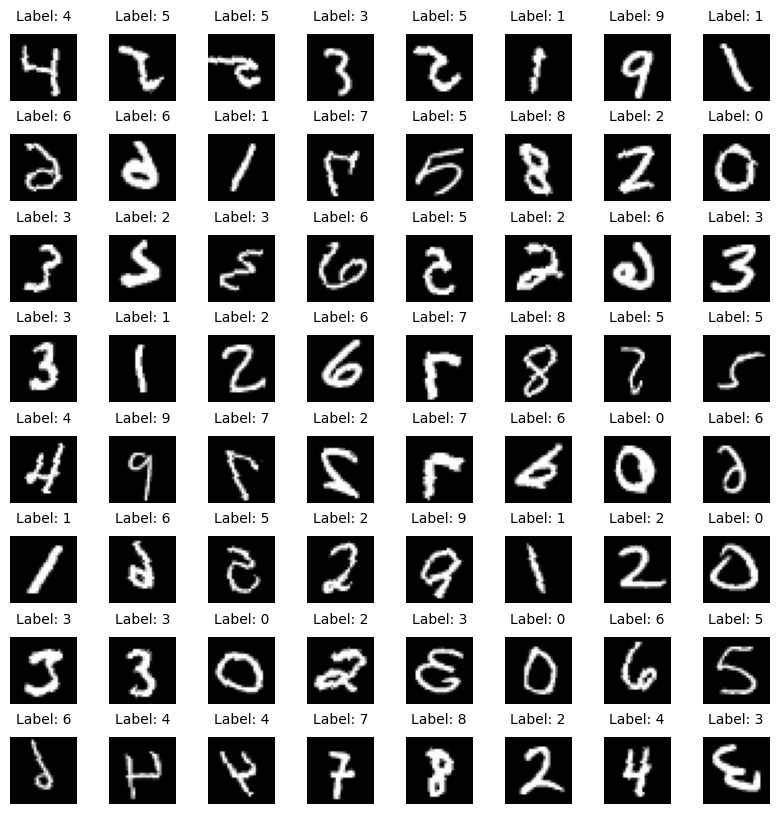

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Function to show a batch of images and labels
def show_batch(batch):
    images, labels = batch
    batch_size = len(images)
    nrows = int(np.sqrt(batch_size))
    ncols = (batch_size // nrows) + (batch_size % nrows > 0)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 10))
    fig.subplots_adjust(hspace=0.5)
    for i, ax in enumerate(axes.flat):
        if i < batch_size:
            ax.imshow(images[i][0], cmap='gray')
            ax.set_title(f'Label: {labels[i].argmax().item()}', fontsize=10, pad=10)
        ax.axis('off')
    plt.show()

# Display a batch of images and their one-hot encoded labels
dataiter = iter(trainloader)
batch = next(dataiter)
show_batch(batch)

Sample One-Hot Encoded Labels:
Label 0: tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])
Label 1: tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0.])
Label 2: tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])
Label 3: tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])
Label 4: tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])


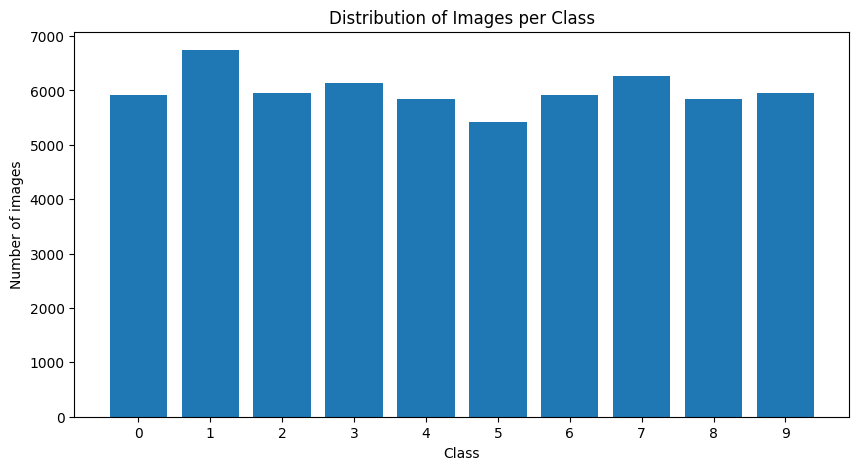

In [7]:
# Display a sample of one-hot encoded labels
def display_sample_labels(loader, num_samples=5):
    dataiter = iter(loader)
    images, one_hot_labels = next(dataiter)
    print("Sample One-Hot Encoded Labels:")
    for i in range(num_samples):
        print(f"Label {i}: {one_hot_labels[i]}")

# Display sample one-hot encoded labels from the trainloader
display_sample_labels(trainloader, num_samples=5)
# Count the number of images per class and visualize the distribution
def visualize_class_distribution(loader):
    class_counts = torch.zeros(10)
    for images, one_hot_labels in loader:
        labels = one_hot_labels.argmax(dim=1)
        for label in labels:
            class_counts[label] += 1

    # Plot the distribution
    classes = [str(i) for i in range(10)]
    plt.figure(figsize=(10, 5))
    plt.bar(classes, class_counts)
    plt.xlabel('Class')
    plt.ylabel('Number of images')
    plt.title('Distribution of Images per Class')
    plt.show()

# Visualize the distribution of images per class in the trainloader
visualize_class_distribution(trainloader)

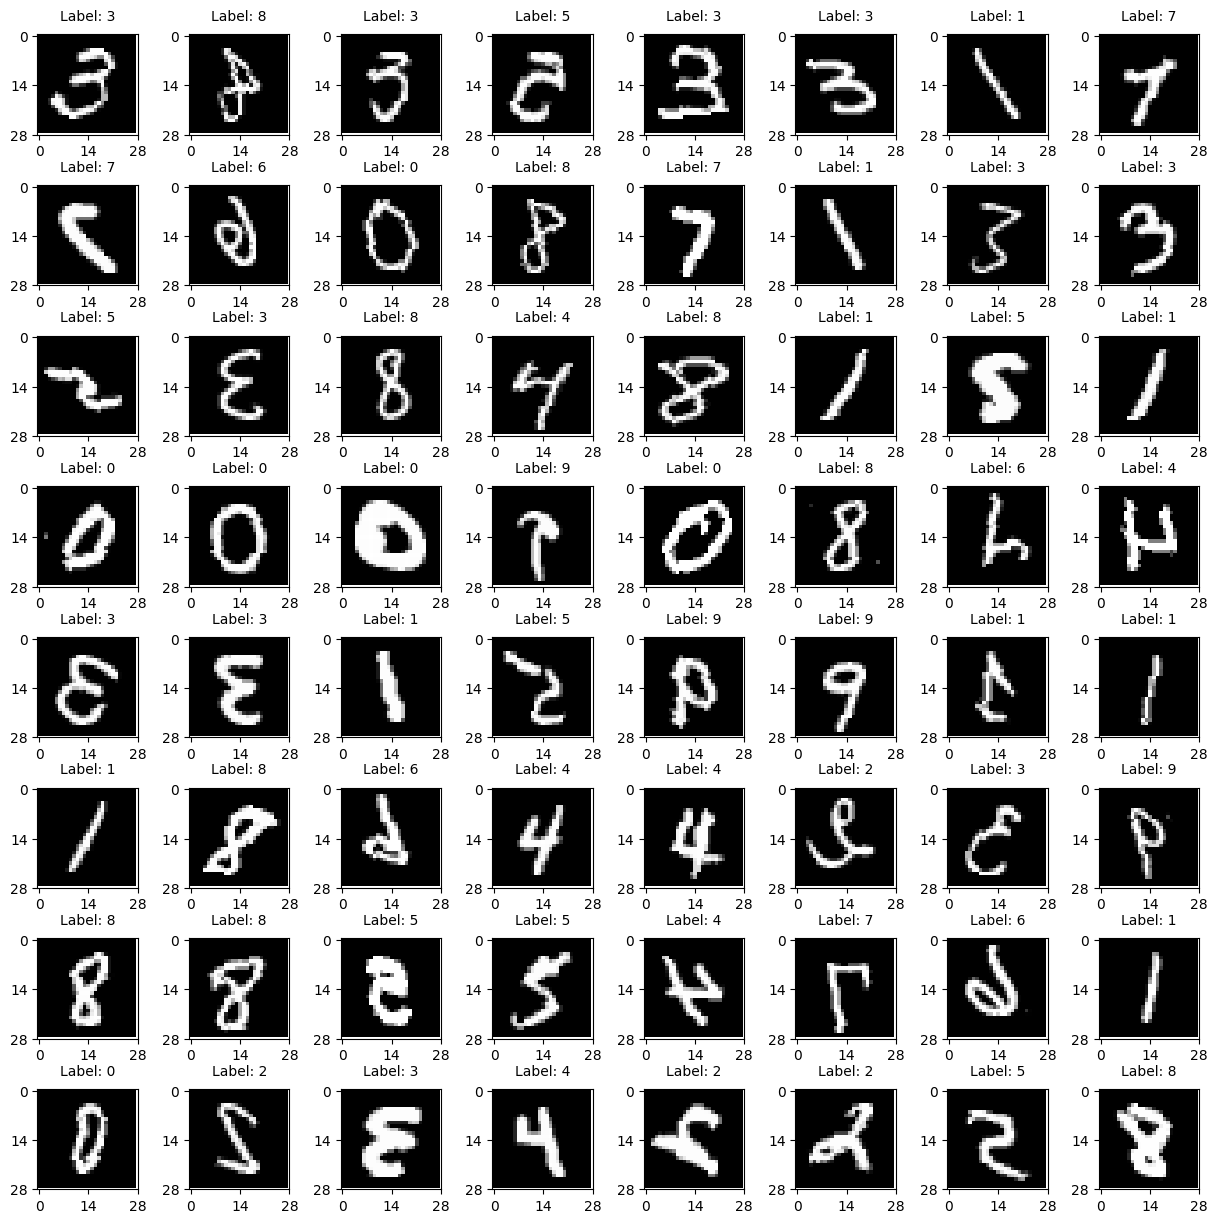

In [8]:
# Function to show a batch of images with their dimensions and labels
def show_batch(batch):
    images, one_hot_labels = batch
    labels = one_hot_labels.argmax(dim=1)  # Convert one-hot labels to class indices
    batch_size = len(images)
    nrows = int(np.sqrt(batch_size))
    ncols = (batch_size // nrows) + (batch_size % nrows > 0)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 15))  # Increased figure size
    fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Added more space between subplots
    for i, ax in enumerate(axes.flat):
        if i < batch_size:
            image = images[i][0]
            ax.imshow(image, cmap='gray')
            ax.set_title(f'Label: {labels[i].item()}', fontsize=10, pad=10)
            # Set custom ticks to show dimensions
            ax.set_xticks([0, image.shape[1]//2, image.shape[1]])
            ax.set_xticklabels([0, image.shape[1]//2, image.shape[1]])
            ax.set_yticks([0, image.shape[0]//2, image.shape[0]])
            ax.set_yticklabels([0, image.shape[0]//2, image.shape[0]])
        ax.axis('on')
    plt.show()

# Load a batch and display it
dataiter = iter(trainloader)
batch = next(dataiter)
show_batch(batch)

In [9]:
from torch.utils.data import random_split

# Define the sizes of train, validation, and test sets
train_size = int(0.7 * len(images))

test_size = len(images) - train_size

# Split the dataset
train_dataset,  test_dataset = random_split(images, [train_size, test_size])



In [10]:
#print sizes of train, validation, and test sets
print(f"Number of samples in the training set: {len(train_dataset)}")

print(f"Number of samples in the test set: {len(test_dataset)}")

Number of samples in the training set: 7000
Number of samples in the test set: 3000


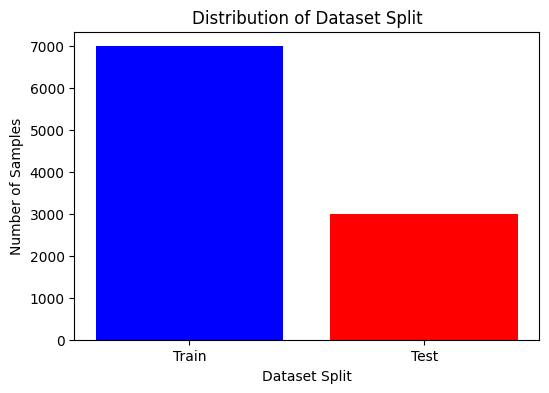

In [11]:
# Sizes of train and test sets
sizes = [len(train_dataset), len(test_dataset)]
labels = ['Train', 'Test']

# Plotting the bar chart
plt.figure(figsize=(6, 4))
plt.bar(labels, sizes, color=['blue', 'red'])
plt.xlabel('Dataset Split')
plt.ylabel('Number of Samples')
plt.title('Distribution of Dataset Split')
plt.show()


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # Convolutional Layer 1: 1 input channel, 6 output channels, kernel size 5x5
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        # Subsampling Layer 1: Average Pooling
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        # Convolutional Layer 2: 6 input channels, 16 output channels, kernel size 5x5
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        # Subsampling Layer 2: Average Pooling
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        # Convolutional Layer 3: Fully connected convolutional layer, 16*5*5 input channels, 120 output channels, kernel size 5x5
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        # Fully Connected Layer 1: 120 input features, 84 output features
        self.fc1 = nn.Linear(120, 84)
        # Fully Connected Layer 2: 84 input features, 10 output features (10 classes)
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        # Apply Convolutional Layer 1 and activation
        x = F.relu(self.conv1(x))
        # Apply Subsampling Layer 1
        x = self.pool1(x)
        # Apply Convolutional Layer 2 and activation
        x = F.relu(self.conv2(x))
        # Apply Subsampling Layer 2
        x = self.pool2(x)
        # Apply Convolutional Layer 3 and activation
        x = F.relu(self.conv3(x))
        # Flatten the tensor for the fully connected layers
        x = x.view(-1, 120)
        # Apply Fully Connected Layer 1 and activation
        x = F.relu(self.fc1(x))
        # Apply Fully Connected Layer 2 (output layer)
        x = self.fc2(x)
        return x

# Initialize the LeNet-5 model
model = LeNet5()

# Print the model architecture
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)


In [13]:
import torch.optim as optim

# Define the loss function (Cross-Entropy Loss for classification)
criterion = nn.CrossEntropyLoss()

# Define the optimizer (Adam optimizer with a learning rate of 0.001)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
# Number of epochs to train
num_epochs = 10

# Training loop
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(trainloader, 0):
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels.argmax(dim=1))  # Use argmax to get class indices from one-hot encoded labels

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Print statistics
        running_loss += loss.item()
        if i % 100 == 99:  # Print every 100 mini-batches
            print(f'[Epoch {epoch + 1}, Mini-batch {i + 1}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

print('Finished Training')

[Epoch 1, Mini-batch 100] loss: 1.406
[Epoch 1, Mini-batch 200] loss: 0.647
[Epoch 1, Mini-batch 300] loss: 0.561
[Epoch 1, Mini-batch 400] loss: 0.460
[Epoch 1, Mini-batch 500] loss: 0.412
[Epoch 1, Mini-batch 600] loss: 0.368
[Epoch 1, Mini-batch 700] loss: 0.311
[Epoch 1, Mini-batch 800] loss: 0.293
[Epoch 1, Mini-batch 900] loss: 0.273
[Epoch 2, Mini-batch 100] loss: 0.230
[Epoch 2, Mini-batch 200] loss: 0.218
[Epoch 2, Mini-batch 300] loss: 0.197
[Epoch 2, Mini-batch 400] loss: 0.181
[Epoch 2, Mini-batch 500] loss: 0.172
[Epoch 2, Mini-batch 600] loss: 0.182
[Epoch 2, Mini-batch 700] loss: 0.173
[Epoch 2, Mini-batch 800] loss: 0.151
[Epoch 2, Mini-batch 900] loss: 0.146
[Epoch 3, Mini-batch 100] loss: 0.135
[Epoch 3, Mini-batch 200] loss: 0.127
[Epoch 3, Mini-batch 300] loss: 0.134
[Epoch 3, Mini-batch 400] loss: 0.115
[Epoch 3, Mini-batch 500] loss: 0.138
[Epoch 3, Mini-batch 600] loss: 0.118
[Epoch 3, Mini-batch 700] loss: 0.126
[Epoch 3, Mini-batch 800] loss: 0.113
[Epoch 3, Mi

In [15]:
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels.argmax(dim=1)).sum().item()

print(f'Accuracy of the model on the test images: {100 * correct / total:.2f}%')

Accuracy of the model on the test images: 98.04%


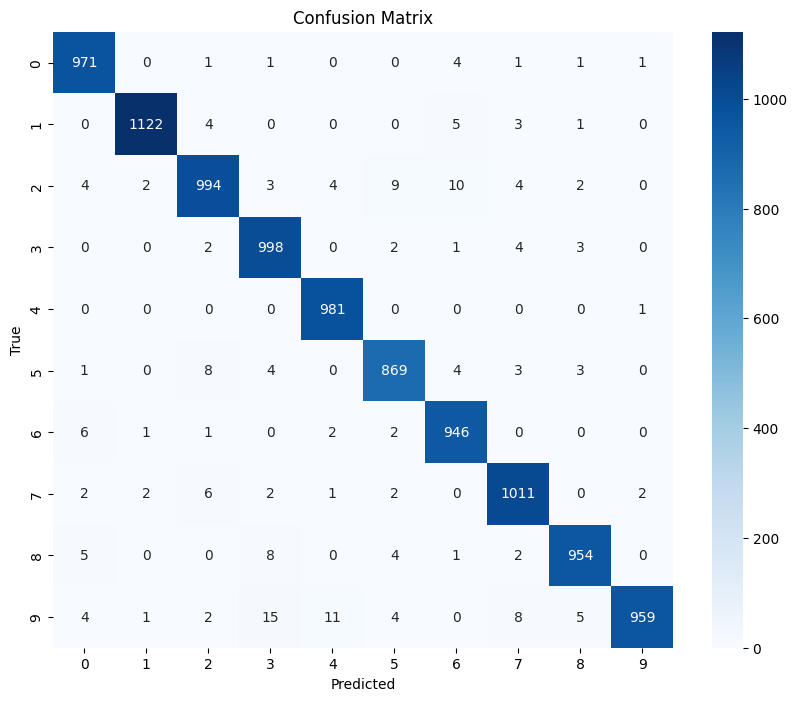

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Calculate the confusion matrix
all_labels = []
all_predictions = []
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_labels.extend(labels.argmax(dim=1).numpy())
        all_predictions.extend(predicted.numpy())

cm = confusion_matrix(all_labels, all_predictions)
plot_confusion_matrix(cm, classes=[str(i) for i in range(10)])

Epoch 1/20
750/750 [==============================] - 12s 8ms/step - loss: 0.4445 - accuracy: 0.8623 - val_loss: 0.1739 - val_accuracy: 0.9452 - lr: 0.0010
Epoch 2/20
750/750 [==============================] - 4s 5ms/step - loss: 0.1831 - accuracy: 0.9449 - val_loss: 0.1289 - val_accuracy: 0.9597 - lr: 0.0010
Epoch 3/20
750/750 [==============================] - 4s 5ms/step - loss: 0.1343 - accuracy: 0.9598 - val_loss: 0.1258 - val_accuracy: 0.9607 - lr: 0.0010
Epoch 4/20
750/750 [==============================] - 5s 6ms/step - loss: 0.1075 - accuracy: 0.9674 - val_loss: 0.1279 - val_accuracy: 0.9604 - lr: 0.0010
Epoch 5/20
750/750 [==============================] - 4s 5ms/step - loss: 0.0892 - accuracy: 0.9727 - val_loss: 0.1049 - val_accuracy: 0.9673 - lr: 0.0010
Epoch 6/20
750/750 [==============================] - 4s 5ms/step - loss: 0.0809 - accuracy: 0.9745 - val_loss: 0.1128 - val_accuracy: 0.9691 - lr: 0.0010
Epoch 7/20
750/750 [==============================] - 5s 6ms/step - l

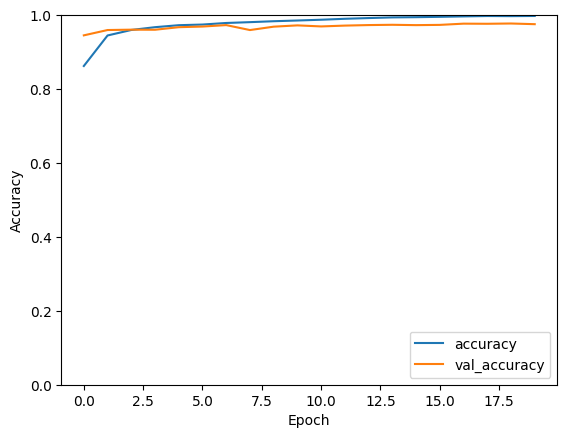

In [17]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Convert DataLoader to NumPy arrays
def dataloader_to_numpy(dataloader):
    images_list, labels_list = [], []
    for images, labels in dataloader:
        images_list.append(images)
        labels_list.append(labels)
    return np.concatenate(images_list), np.concatenate(labels_list)

train_images, train_labels = dataloader_to_numpy(trainloader)
test_images, test_labels = dataloader_to_numpy(testloader)

# Reshape images to add the channel dimension
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

# Define the CNN model
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Increased dropout for regularization
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Define a learning rate scheduler
def lr_scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_scheduler)

# Train the model
history = model.fit(train_images, train_labels, epochs=20, batch_size=64, validation_split=0.2, callbacks=[lr_callback])

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc:.2%}")

# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()